# Лабораторная работа № 1
## Настройка окружения и разведочный анализ Heart Disease Dataset

**Студент:** Лукожев Ильяс Хусенович  
**Группа:** А-02м-25

Цель: подготовить воспроизводимую структуру проекта, очистить табличные данные и исследовать признаки, связанные с наличием сердечно-сосудистого заболевания.

Задача — **бинарная классификация**. Целевая переменная `target`: 0 — заболевание не выявлено, 1 — заболевание присутствует.

> Результаты являются учебным анализом и не предназначены для медицинской диагностики.

## 1. Загрузка данных и знакомство с ними

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="Set2")

# Блокнот можно запускать как из корня проекта, так и из папки eda.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "heart_disease.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "heart_disease.csv"
EDA_DIR = PROJECT_ROOT / "eda"
EDA_DIR.mkdir(exist_ok=True)

print(f"Корень проекта: {PROJECT_ROOT.resolve()}")
print(f"Датасет: {DATA_PATH.resolve()}")

Корень проекта: /home/mainuser/lab/heart-disease-eda
Датасет: /home/mainuser/lab/heart-disease-eda/data/heart_disease.csv


### Описание столбцов

| Столбец | Смысл | Тип признака |
|---|---|---|
| `age` | возраст, лет | числовой |
| `sex` | пол: 0 — женский, 1 — мужской | категориальный |
| `cp` | тип боли в груди: 1–4 | категориальный |
| `trestbps` | давление в покое, мм рт. ст. | числовой |
| `chol` | холестерин, мг/дл | числовой |
| `fbs` | сахар натощак > 120 мг/дл | категориальный |
| `restecg` | результат ЭКГ в покое | категориальный |
| `thalach` | максимальная достигнутая ЧСС | числовой |
| `exang` | стенокардия при нагрузке | категориальный |
| `oldpeak` | депрессия ST при нагрузке относительно покоя | числовой |
| `slope` | наклон сегмента ST при пиковой нагрузке | категориальный |
| `ca` | число крупных сосудов, видимых при флюороскопии | дискретный числовой |
| `thal` | результат теста талассемии | категориальный |
| `num` | исходный диагноз: 0–4 | целевая переменная |

Источник: UCI Machine Learning Repository, Cleveland subset. Исходный файл не содержит строки заголовков, поэтому имена задаются при чтении.

In [2]:
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num",
]

df_raw = pd.read_csv(DATA_PATH, names=columns, na_values="?")
df = df_raw.copy()

print(f"Размер исходных данных: {df.shape[0]} строк × {df.shape[1]} столбцов")
display(df.head())

Размер исходных данных: 303 строк × 14 столбцов


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
print("Типы и заполненность столбцов:")
df.info()

Типы и заполненность столбцов:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [4]:
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]
target_source = "num"

print("Числовые признаки:", numeric_features)
print("Категориальные признаки:", categorical_features)
print("Исходная целевая переменная:", target_source)
display(df[numeric_features + [target_source]].describe().T)

Числовые признаки: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
Категориальные признаки: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Исходная целевая переменная: num


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2
ca,299.0,0.672241,0.937438,0.0,0.0,0.0,1.0,3.0
num,303.0,0.937294,1.228536,0.0,0.0,0.0,2.0,4.0


In [5]:
categorical_summary = pd.DataFrame({
    "уникальных": df[categorical_features].nunique(dropna=True),
    "мода": df[categorical_features].mode(dropna=True).iloc[0],
    "пропусков": df[categorical_features].isna().sum(),
})
display(categorical_summary)

,уникальных,мода,пропусков
sex,2,1.0,0
cp,4,4.0,0
fbs,2,0.0,0
restecg,3,0.0,0
exang,2,0.0,0
slope,3,1.0,0
thal,3,3.0,2


**Первичный вывод.** Датасет соответствует условиям работы: 303 объекта и 13 входных признаков, среди которых есть числовые и категориальные. `ca` и `thal` прочитаны как `float64` из-за маркера `?`; после обработки пропусков типы будут исправлены. Исходный диагноз `num` принимает значения 0–4, для дальнейшей бинарной классификации его нужно преобразовать.

## 2. Очистка данных

In [6]:
quality_report = pd.DataFrame({
    "тип": df.dtypes.astype(str),
    "пропуски": df.isna().sum(),
    "доля_пропусков_%": (df.isna().mean() * 100).round(2),
    "уникальные": df.nunique(dropna=True),
})
display(quality_report)
print("Полных дубликатов:", df.duplicated().sum())

,тип,пропуски,доля_пропусков_%,уникальные
age,float64,0,0.00,41
sex,float64,0,0.00,2
cp,float64,0,0.00,4
trestbps,float64,0,0.00,50
chol,float64,0,0.00,152
fbs,float64,0,0.00,2
restecg,float64,0,0.00,3
thalach,float64,0,0.00,91
exang,float64,0,0.00,2
oldpeak,float64,0,0.00,40


Полных дубликатов: 0


In [7]:
# Проверка допустимых диапазонов. Нарушения переводятся в пропуски,
# чтобы затем обработать их единообразно.
valid_ranges = {
    "age": (18, 100),
    "trestbps": (50, 250),
    "chol": (50, 700),
    "thalach": (50, 250),
    "oldpeak": (0, 10),
    "ca": (0, 3),
    "num": (0, 4),
}
valid_categories = {
    "sex": {0, 1}, "cp": {1, 2, 3, 4}, "fbs": {0, 1},
    "restecg": {0, 1, 2}, "exang": {0, 1},
    "slope": {1, 2, 3}, "thal": {3, 6, 7},
}

invalid_counts = {}
for column, (lower, upper) in valid_ranges.items():
    invalid = df[column].notna() & ~df[column].between(lower, upper)
    invalid_counts[column] = int(invalid.sum())
    df.loc[invalid, column] = pd.NA

for column, allowed in valid_categories.items():
    invalid = df[column].notna() & ~df[column].isin(allowed)
    invalid_counts[column] = int(invalid.sum())
    df.loc[invalid, column] = pd.NA

print("Невалидные значения по столбцам:", invalid_counts)

Невалидные значения по столбцам: {'age': 0, 'trestbps': 0, 'chol': 0, 'thalach': 0, 'oldpeak': 0, 'ca': 0, 'num': 0, 'sex': 0, 'cp': 0, 'fbs': 0, 'restecg': 0, 'exang': 0, 'slope': 0, 'thal': 0}


In [8]:
# Дубликаты удаляем. В данном наборе их нет, но операция делает pipeline устойчивым.
rows_before = len(df)
df = df.drop_duplicates().copy()
duplicates_removed = rows_before - len(df)

# ca и thal имеют очень мало пропусков; заполняем модой, сохраняя все 303 объекта.
missing_before = df.isna().sum()
imputation_values = {}
for column in ["ca", "thal"]:
    fill_value = df[column].mode(dropna=True).iloc[0]
    imputation_values[column] = fill_value
    df[column] = df[column].fillna(fill_value)

# На случай появления пропусков после проверки диапазонов:
for column in ["age", "trestbps", "chol", "thalach", "oldpeak"]:
    if df[column].isna().any():
        fill_value = df[column].median()
        imputation_values[column] = fill_value
        df[column] = df[column].fillna(fill_value)
for column in ["sex", "cp", "fbs", "restecg", "exang", "slope"]:
    if df[column].isna().any():
        fill_value = df[column].mode(dropna=True).iloc[0]
        imputation_values[column] = fill_value
        df[column] = df[column].fillna(fill_value)

print("Удалено дубликатов:", duplicates_removed)
print("Заполнено пропусков:", missing_before[missing_before > 0].to_dict())
print("Значения для заполнения:", imputation_values)

Удалено дубликатов: 0
Заполнено пропусков: {'ca': 4, 'thal': 2}
Значения для заполнения: {'ca': np.float64(0.0), 'thal': np.float64(3.0)}


In [9]:
# Бинаризация цели и приведение типов.
df["target"] = (df["num"] > 0).astype("int8")
df = df.drop(columns="num")

integer_columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "slope", "ca", "thal",
]
df[integer_columns] = df[integer_columns].astype("int64")

for column in categorical_features:
    df[column] = df[column].astype("category")

# Новый интерпретируемый признак для сравнения возрастных групп.
df["age_group"] = pd.cut(
    df["age"], bins=[0, 44, 54, 64, float("inf")],
    labels=["<45", "45–54", "55–64", "65+"],
)

clean_df = df.copy()
assert clean_df.isna().sum().sum() == 0
assert clean_df.duplicated().sum() == 0
assert set(clean_df["target"].unique()) <= {0, 1}

print(f"Размер очищенных данных: {clean_df.shape}")
display(clean_df.head())
display(clean_df.dtypes.rename("dtype").to_frame())

Размер очищенных данных: (303, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0,55–64
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,1,65+
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1,65+
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0,<45
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0,<45


,dtype
age,int64
sex,category
cp,category
trestbps,int64
chol,int64
fbs,category
restecg,category
thalach,int64
exang,category
oldpeak,float64


In [10]:
clean_path = PROJECT_ROOT / "data" / "clean_dataset.pkl"
clean_df.to_pickle(clean_path)
print(f"Очищенный датасет сохранен: {clean_path.resolve()}")
print(f"Размер файла: {clean_path.stat().st_size / 1024:.1f} КБ")

Очищенный датасет сохранен: /home/mainuser/lab/heart-disease-eda/data/clean_dataset.pkl
Размер файла: 19.2 КБ


**Вывод по очистке.** Полных дубликатов и значений за установленными допустимыми диапазонами не обнаружено. Четыре пропуска `ca` и два пропуска `thal` заполнены модами соответствующих столбцов — доля пропусков мала, поэтому удалять строки нецелесообразно. Категориальные признаки приведены к типу `category`, целочисленные — к `int64`, цель — к `int8`. Создан новый категориальный признак `age_group`. Очищенные данные сохранены в `data/clean_dataset.pkl` с сохранением типов.

## 3. Анализ признаков для модели

### График 1. Баланс классов целевой переменной

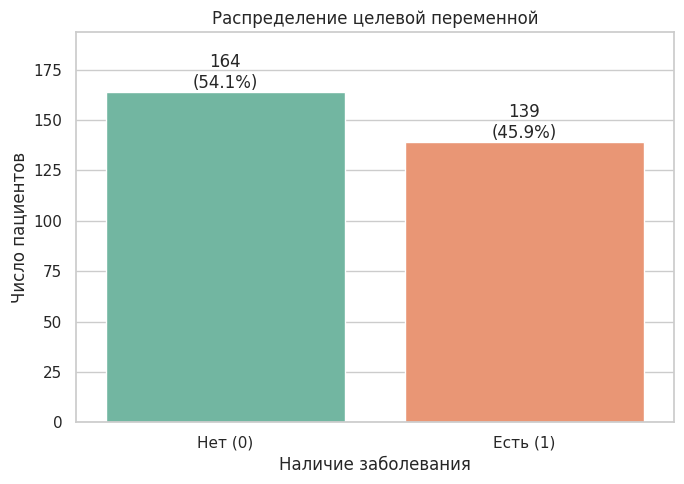

Доли классов, %: {0: 54.1, 1: 45.9}


In [11]:
class_counts = clean_df["target"].value_counts().sort_index()
class_share = (class_counts / len(clean_df) * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=clean_df, x="target", hue="target", legend=False, ax=ax)
ax.set(title="Распределение целевой переменной", xlabel="Наличие заболевания", ylabel="Число пациентов")
ax.set_xticks([0, 1], ["Нет (0)", "Есть (1)"])
ax.set_ylim(0, class_counts.max() * 1.18)
for patch, count in zip(ax.patches, class_counts):
    ax.annotate(f"{count}\n({count / len(clean_df):.1%})", (patch.get_x() + patch.get_width()/2, patch.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.savefig(EDA_DIR / "01_target_distribution.png", dpi=160, bbox_inches="tight")
plt.show()
print("Доли классов, %:", class_share.to_dict())

**Вывод:** классы сравнительно сбалансированы: 164 пациента без заболевания (54,1%) и 139 с заболеванием (45,9%). Сильного дисбаланса нет; accuracy допустима как дополнительная метрика, однако при моделировании следует также использовать recall, precision, F1 и ROC-AUC.

### График 2. Возраст в зависимости от целевого класса

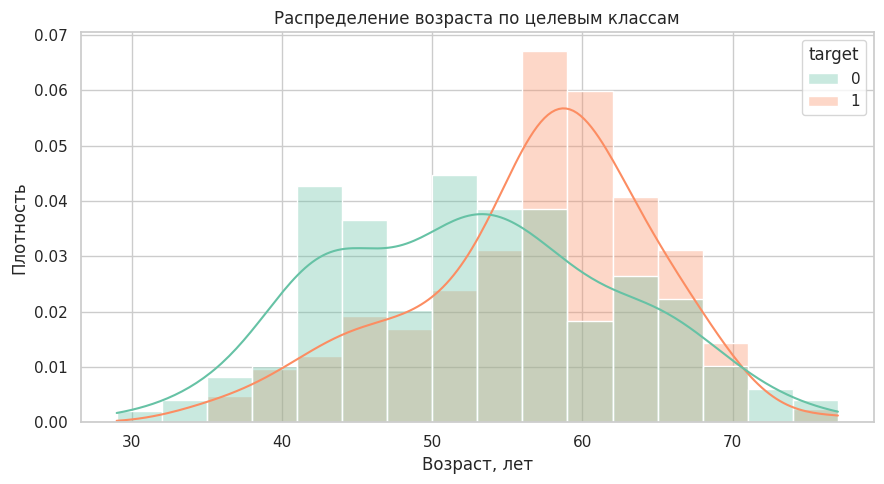

,mean,median,std
target,,,
0,52.59,52.0,9.51
1,56.63,58.0,7.94


In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=clean_df, x="age", hue="target", bins=16, kde=True,
             stat="density", common_norm=False, alpha=0.35, ax=ax)
ax.set(title="Распределение возраста по целевым классам", xlabel="Возраст, лет", ylabel="Плотность")
plt.tight_layout()
plt.savefig(EDA_DIR / "02_age_by_target.png", dpi=160, bbox_inches="tight")
plt.show()
display(clean_df.groupby("target")["age"].agg(["mean", "median", "std"]).round(2))

**Вывод:** пациенты с заболеванием в среднем старше (56,6 года против 52,6). Распределения заметно перекрываются, поэтому возраст полезен в сочетании с другими признаками, но сам по себе недостаточен для надежной классификации.

### График 3. Доля заболевания по типу боли в груди

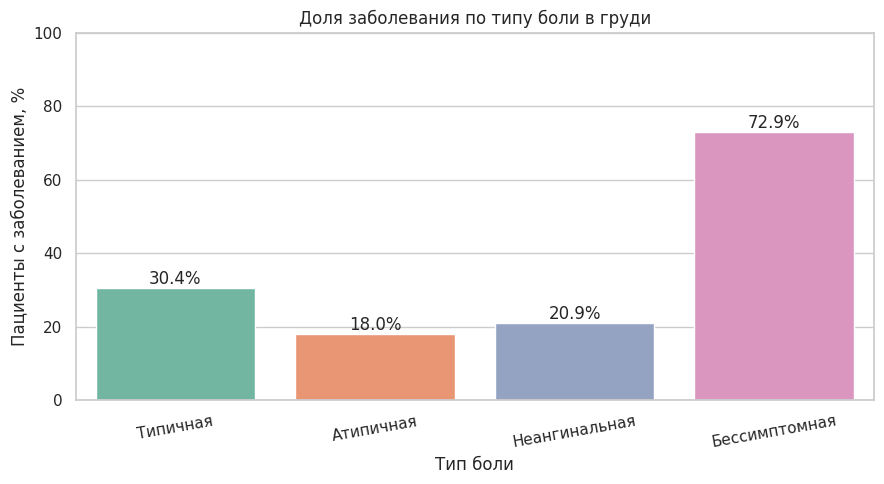

In [13]:
cp_labels = {1: "Типичная", 2: "Атипичная", 3: "Неангинальная", 4: "Бессимптомная"}
cp_rate = (clean_df.assign(cp_num=clean_df["cp"].astype(int))
           .groupby("cp_num", observed=False)["target"].mean().mul(100)
           .rename(index=cp_labels))

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=cp_rate.index, y=cp_rate.values, hue=cp_rate.index, legend=False, ax=ax)
ax.set(title="Доля заболевания по типу боли в груди", xlabel="Тип боли", ylabel="Пациенты с заболеванием, %", ylim=(0, 100))
for patch, value in zip(ax.patches, cp_rate.values):
    ax.annotate(f"{value:.1f}%", (patch.get_x() + patch.get_width()/2, patch.get_height()), ha="center", va="bottom")
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(EDA_DIR / "03_disease_rate_by_chest_pain.png", dpi=160, bbox_inches="tight")
plt.show()

**Вывод:** максимальная доля положительного класса наблюдается при бессимптомном типе боли — 72,9%; для остальных типов она составляет 18–30%. `cp` выглядит одним из наиболее информативных категориальных признаков. Код значения не следует трактовать как обычную непрерывную шкалу.

### График 4. Максимальная ЧСС по целевым классам

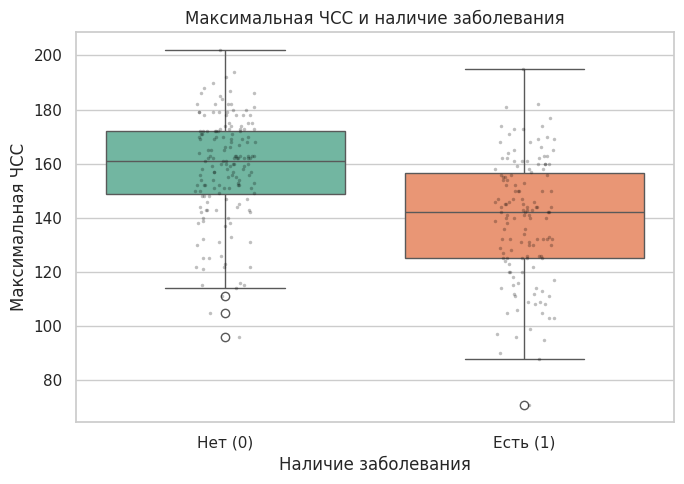

,mean,median
target,,
0,158.4,161.0
1,139.3,142.0


In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=clean_df, x="target", y="thalach", hue="target", legend=False, ax=ax)
sns.stripplot(data=clean_df, x="target", y="thalach", color="black", alpha=0.25, size=2.5, ax=ax)
ax.set(title="Максимальная ЧСС и наличие заболевания", xlabel="Наличие заболевания", ylabel="Максимальная ЧСС")
ax.set_xticks([0, 1], ["Нет (0)", "Есть (1)"])
plt.tight_layout()
plt.savefig(EDA_DIR / "04_thalach_by_target.png", dpi=160, bbox_inches="tight")
plt.show()
display(clean_df.groupby("target")["thalach"].agg(["mean", "median"]).round(1))

**Вывод:** у пациентов с заболеванием максимальная достигнутая ЧСС ниже: среднее 139,3 против 158,4. Признак `thalach` потенциально полезен, причем его связь с целью может зависеть от возраста.

### График 5. Стенокардия при нагрузке и целевая переменная

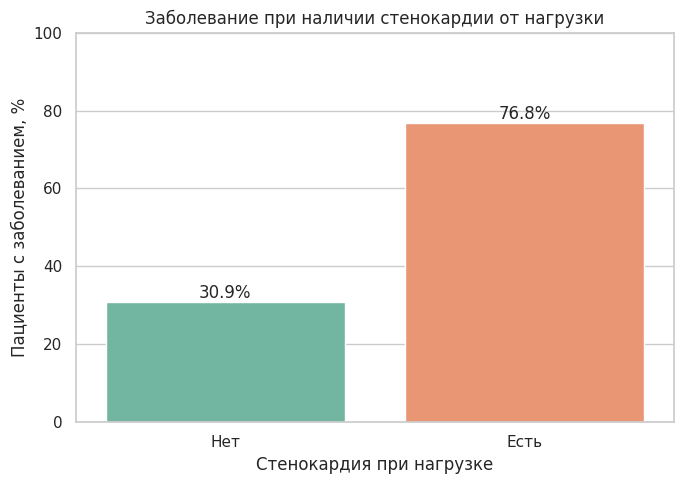

In [15]:
exang_rate = (clean_df.assign(exang_num=clean_df["exang"].astype(int))
              .groupby("exang_num", observed=False)["target"].mean().mul(100))

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=["Нет", "Есть"], y=exang_rate.values, hue=["Нет", "Есть"], legend=False, ax=ax)
ax.set(title="Заболевание при наличии стенокардии от нагрузки", xlabel="Стенокардия при нагрузке", ylabel="Пациенты с заболеванием, %", ylim=(0, 100))
for patch, value in zip(ax.patches, exang_rate.values):
    ax.annotate(f"{value:.1f}%", (patch.get_x() + patch.get_width()/2, patch.get_height()), ha="center", va="bottom")
plt.tight_layout()
plt.savefig(EDA_DIR / "05_disease_rate_by_exang.png", dpi=160, bbox_inches="tight")
plt.show()

**Вывод:** среди пациентов со стенокардией при нагрузке заболевание присутствует у 76,8%, без нее — у 30,9%. `exang` демонстрирует сильную связь с целью и должен быть включен в модель.

### График 6. Депрессия сегмента ST по целевым классам

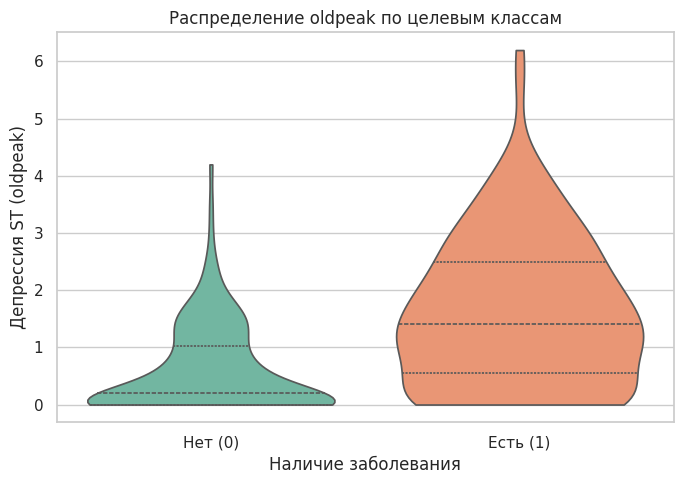

,mean,median
target,,
0,0.59,0.2
1,1.57,1.4


In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.violinplot(data=clean_df, x="target", y="oldpeak", hue="target", legend=False,
               inner="quart", cut=0, ax=ax)
ax.set(title="Распределение oldpeak по целевым классам", xlabel="Наличие заболевания", ylabel="Депрессия ST (oldpeak)")
ax.set_xticks([0, 1], ["Нет (0)", "Есть (1)"])
plt.tight_layout()
plt.savefig(EDA_DIR / "06_oldpeak_by_target.png", dpi=160, bbox_inches="tight")
plt.show()
display(clean_df.groupby("target")["oldpeak"].agg(["mean", "median"]).round(2))

**Вывод:** `oldpeak` заметно выше в положительном классе: среднее 1,57 против 0,59. Распределение асимметрично и содержит высокие значения; для линейных моделей может быть полезно масштабирование или устойчивое преобразование.

### График 7. Корреляции числовых признаков

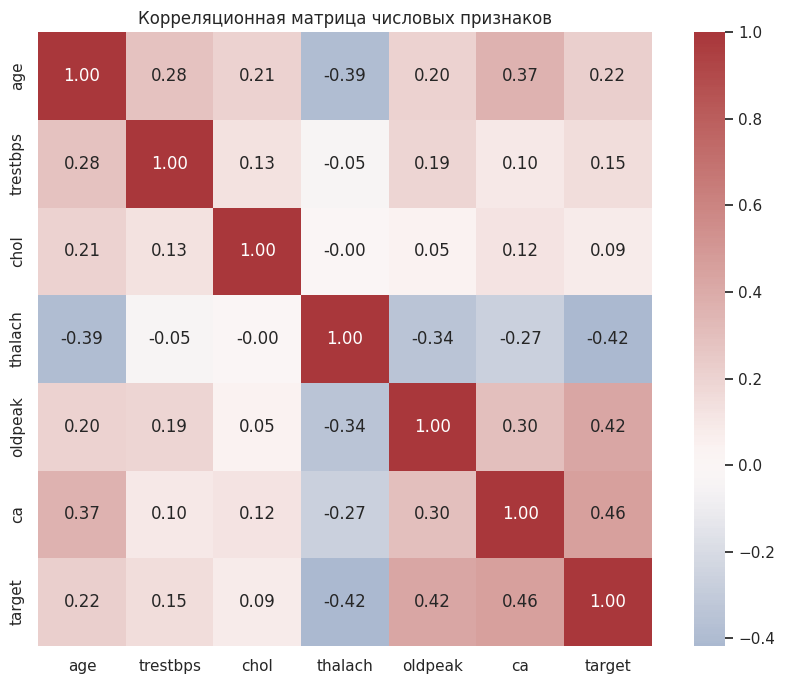

,corr_with_target
ca,0.460033
oldpeak,0.424510
thalach,-0.417167
age,0.223120
trestbps,0.150825
chol,0.085164


In [17]:
corr_columns = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca", "target"]
corr = clean_df[corr_columns].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, ax=ax)
ax.set_title("Корреляционная матрица числовых признаков")
plt.tight_layout()
plt.savefig(EDA_DIR / "07_correlation_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()
display(corr["target"].drop("target").sort_values(key=lambda s: s.abs(), ascending=False).to_frame("corr_with_target"))

**Вывод:** среди рассмотренных числовых признаков с целью сильнее всего связаны `ca` (положительно), `oldpeak` (положительно) и `thalach` (отрицательно). Парные корреляции между входными числовыми признаками невысоки; явной сильной мультиколлинеарности в этом подмножестве нет. Корреляция не доказывает причинность и не отражает нелинейные зависимости.

### График 8. Интерактивная связь возраста и максимальной ЧСС

In [18]:
plot_df = clean_df.copy()
plot_df["target_label"] = plot_df["target"].map({0: "Нет заболевания", 1: "Есть заболевание"})
plot_df["cp_code"] = plot_df["cp"].astype(int)

interactive_fig = px.scatter(
    plot_df,
    x="age",
    y="thalach",
    color="target_label",
    symbol="target_label",
    hover_data=["sex", "cp_code", "trestbps", "chol", "oldpeak", "ca"],
    labels={"age": "Возраст, лет", "thalach": "Максимальная ЧСС", "target_label": "Класс"},
    title="Возраст, максимальная ЧСС и наличие заболевания",
    opacity=0.75,
)
interactive_fig.update_layout(legend_title_text="Целевой класс")
interactive_path = EDA_DIR / "08_interactive_age_thalach.html"
interactive_fig.write_html(interactive_path, include_plotlyjs="cdn")
interactive_fig.show()
print(f"Интерактивный график сохранен: {interactive_path.resolve()}")

Интерактивный график сохранен: /home/mainuser/lab/heart-disease-eda/eda/08_interactive_age_thalach.html


**Вывод:** интерактивный график подтверждает совместную закономерность: положительный класс чаще встречается у более возрастных пациентов с меньшей максимальной ЧСС, однако зоны классов перекрываются. В модели стоит проверить нелинейность и взаимодействие `age × thalach`. HTML-файл позволяет просматривать значения отдельных наблюдений при наведении.

## 4. Сохранение финального датасета

In [19]:
# Контроль чтения pickle и сохраненных типов.
restored_df = pd.read_pickle(PROJECT_ROOT / "data" / "clean_dataset.pkl")
pd.testing.assert_frame_equal(clean_df, restored_df)

artifacts = sorted(path.name for path in EDA_DIR.glob("*.png"))
artifacts += sorted(path.name for path in EDA_DIR.glob("*.html"))
print("Финальный датасет успешно проверен.")
print("Сохраненные графики:")
for artifact in artifacts:
    print(" -", artifact)

Финальный датасет успешно проверен.
Сохраненные графики:
 - 01_target_distribution.png
 - 02_age_by_target.png
 - 03_disease_rate_by_chest_pain.png
 - 04_thalach_by_target.png
 - 05_disease_rate_by_exang.png
 - 06_oldpeak_by_target.png
 - 07_correlation_heatmap.png
 - 08_interactive_age_thalach.html


## 5. Итоговые выводы

### Что сделано при очистке

1. Маркеры `?` при чтении преобразованы в пропуски.
2. Проверены полные дубликаты — не обнаружены.
3. Проверены допустимые диапазоны и категории — невалидных значений не обнаружено.
4. Четыре пропуска в `ca` и два в `thal` заполнены модой соответствующего признака.
5. Исправлены типы: категориальные признаки получили тип `category`, счетчики — целочисленный тип.
6. Исходная цель `num` преобразована в бинарную `target = (num > 0)`.
7. Очищенный набор сохранен в `data/clean_dataset.pkl`; повторное чтение и типы проверены.

### Новые признаки

Создан `age_group` с интервалами `<45`, `45–54`, `55–64`, `65+`. Для будущего моделирования также стоит проверить взаимодействие возраста и максимальной ЧСС.

### Полезные закономерности

- Классы близки к сбалансированным: 54,1% отрицательных и 45,9% положительных наблюдений.
- С заболеванием связаны более высокий возраст и более низкая максимальная ЧСС.
- Бессимптомный тип боли (`cp = 4`) имеет существенно большую долю положительного класса.
- Стенокардия при нагрузке (`exang = 1`) связана с высокой долей заболевания.
- `oldpeak` и число видимых крупных сосудов `ca` выше в положительном классе.
- Наиболее перспективные признаки по EDA: `cp`, `exang`, `thalach`, `oldpeak`, `ca`, а также возраст.

Выводы описывают связи именно в этой небольшой выборке из 303 пациентов. Для оценки обобщающей способности будущей модели потребуются стратифицированное разбиение и кросс-валидация; медицинские причинные выводы по EDA делать нельзя.